In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.layers import Dense, Input
from keras.models import Sequential
import warnings 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [188]:
df = pd.read_csv('../data/lab09/WineQT.csv')

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [189]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [190]:
df.drop(columns=['id'], inplace=True, errors='ignore')

In [209]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.utils import to_categorical

X = df.drop(columns=['quality'])
y = df['quality'] - df['quality'].min()

y_encoded = to_categorical(y, num_classes=6)

ss = StandardScaler()
X_scaled = ss.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, train_size=0.7, stratify=y, random_state=42)
X_test_test, X_test_validation, y_test_test, y_test_validation = train_test_split(X_test, y_test, train_size=0.6, stratify=np.argmax(y_test, axis=1), random_state=42)

In [240]:
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy
from keras.optimizers import Adam
from keras.regularizers import L2
from keras.layers import Dropout

model = Sequential([
  Input(shape=(df.shape[1] - 1,)),
  Dense(64, 'relu', kernel_regularizer=L2(0.01)),
  Dropout(0.3),
  Dense(32, 'relu', kernel_regularizer=L2(0.01)),
  Dropout(0.3),
  Dense(6, 'softmax', kernel_regularizer=L2(0.01))
])

model.compile(
  optimizer=Adam(),
  loss=CategoricalCrossentropy(),
  metrics=[CategoricalAccuracy()]
)

In [241]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
  X_train, y_train,
  batch_size=32, epochs=150,
  validation_data=(X_test_test, y_test_test),
  callbacks=[early_stop],
  verbose=1
)

Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - categorical_accuracy: 0.2500 - loss: 2.4855 - val_categorical_accuracy: 0.4878 - val_loss: 2.1489
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - categorical_accuracy: 0.2500 - loss: 2.4855 - val_categorical_accuracy: 0.4878 - val_loss: 2.1489
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.4400 - loss: 2.1222 - val_categorical_accuracy: 0.5707 - val_loss: 1.8886
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.4400 - loss: 2.1222 - val_categorical_accuracy: 0.5707 - val_loss: 1.8886
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - categorical_accuracy: 0.4725 - loss: 1.9254 - val_categorical_accuracy: 0.5902 - val_loss: 1.7371
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - categorical_accuracy: 0.4725 - loss: 1.9254 - val_categorical_accuracy: 0.5902 - val_loss: 1.7371
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5250 - loss: 1.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Accuracy: 0.6159


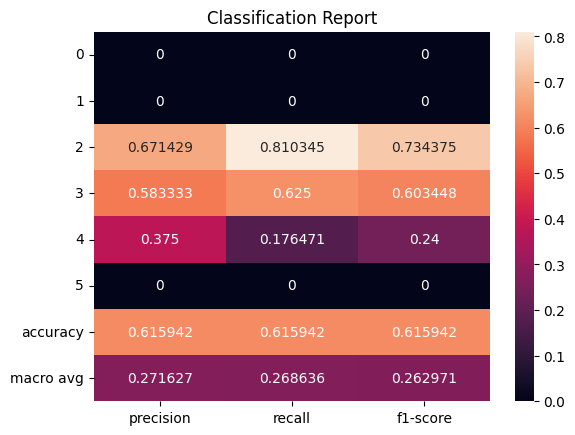

In [249]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_probs = model.predict(X_test_validation)
y_pred = np.argmax(y_pred_probs, axis=1)

y_real = np.argmax(y_test_validation, axis=1)

acc = accuracy_score(y_real, y_pred)
print(f"\nAccuracy: {acc:.4f}")

classification_df = pd.DataFrame(classification_report(y_real, y_pred, output_dict=True)).T.iloc[0:-1, 0:-1]
sns.heatmap(classification_df, annot=True, fmt='g')
plt.title("Classification Report")
plt.show()

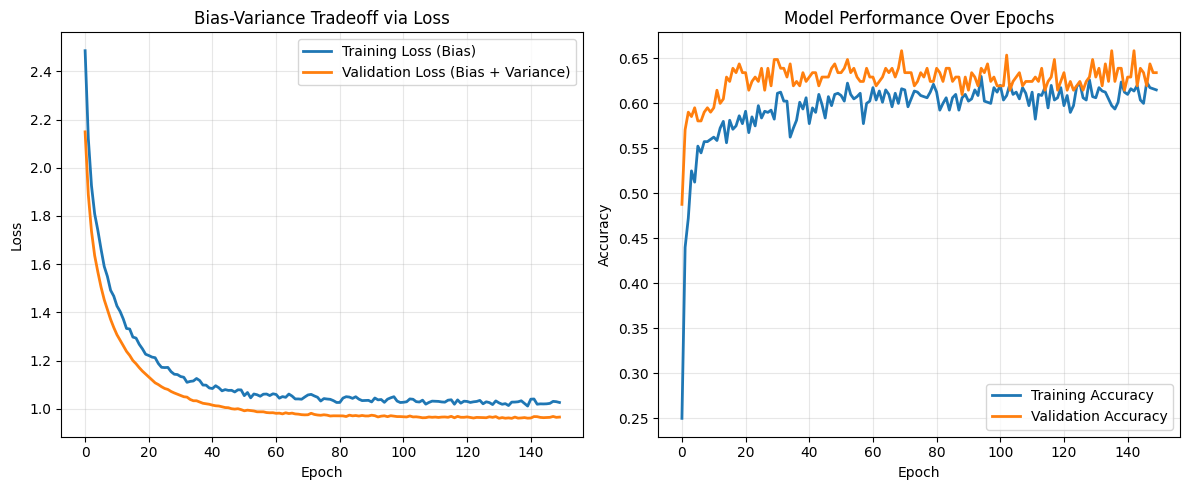


Bias-Variance Analysis:
Final Training Loss: 1.0266 (Bias)
Final Validation Loss: 0.9660 (Bias + Variance)
Gap (Variance): -0.0606


In [245]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss (Bias)', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (Bias + Variance)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Bias-Variance Tradeoff via Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['categorical_accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Performance Over Epochs')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
gap = final_val_loss - final_train_loss

print(f"\nBias-Variance Analysis:")
print(f"Final Training Loss: {final_train_loss:.4f} (Bias)")
print(f"Final Validation Loss: {final_val_loss:.4f} (Bias + Variance)")
print(f"Gap (Variance): {gap:.4f}")

In [262]:
df = pd.read_csv('../data/lab09/data.csv')

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [268]:
df.head()

,date,price,bedrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_basement,yr_built,yr_renovated,street,city,statezip
0,2014-05-02 00:00:00,313000.0,3.0,1340,7912,1.5,0,0,3,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133
1,2014-05-02 00:00:00,2384000.0,5.0,3650,9050,2.0,0,4,5,280,1921,0,709 W Blaine St,Seattle,WA 98119
2,2014-05-02 00:00:00,342000.0,3.0,1930,11947,1.0,0,0,4,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042
3,2014-05-02 00:00:00,420000.0,3.0,2000,8030,1.0,0,0,4,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008
4,2014-05-02 00:00:00,550000.0,4.0,1940,10500,1.0,0,0,4,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052


In [273]:
print(df.columns.tolist())

for col in df.select_dtypes(exclude='number'):
  print(col, df[col].nunique())
  display(df[col].value_counts())

['date', 'price', 'bedrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip']
date 70


date
2014-06-23 00:00:00    142
2014-06-25 00:00:00    131
2014-06-26 00:00:00    131
2014-07-08 00:00:00    127
2014-07-09 00:00:00    121
                      ... 
2014-06-07 00:00:00      4
2014-07-06 00:00:00      3
2014-05-11 00:00:00      2
2014-07-04 00:00:00      2
2014-05-17 00:00:00      1
Name: count, Length: 70, dtype: int64

street 4525


street
2520 Mulberry Walk NE    4
2500 Mulberry Walk NE    3
11716 16th Ave NE        2
35229 SE Terrace St      2
13800 453rd Ave SE       2
                        ..
501 N 143rd St           1
14855 SE 10th Pl         1
759 Ilwaco Pl NE         1
5148 S Creston St        1
8519 28th Ave NW         1
Name: count, Length: 4525, dtype: int64

city 44


city
Seattle                1573
Renton                  293
Bellevue                286
Redmond                 235
Kirkland                187
Issaquah                187
Kent                    185
Auburn                  176
Sammamish               175
Federal Way             148
Shoreline               123
Woodinville             115
Maple Valley             96
Mercer Island            86
Burien                   74
Snoqualmie               71
Kenmore                  66
Des Moines               58
North Bend               50
Covington                43
Duvall                   42
Lake Forest Park         36
Bothell                  33
Newcastle                33
Tukwila                  29
SeaTac                   29
Vashon                   29
Enumclaw                 28
Carnation                22
Normandy Park            18
Clyde Hill               11
Fall City                11
Medina                   11
Black Diamond             9
Ravensdale                7
Pacific        

statezip 77


statezip
WA 98103    148
WA 98052    135
WA 98117    132
WA 98115    130
WA 98006    110
           ... 
WA 98047      6
WA 98288      3
WA 98050      2
WA 98354      2
WA 98068      1
Name: count, Length: 77, dtype: int64

In [270]:
df.drop(columns=['country'], inplace=True, errors='ignore')

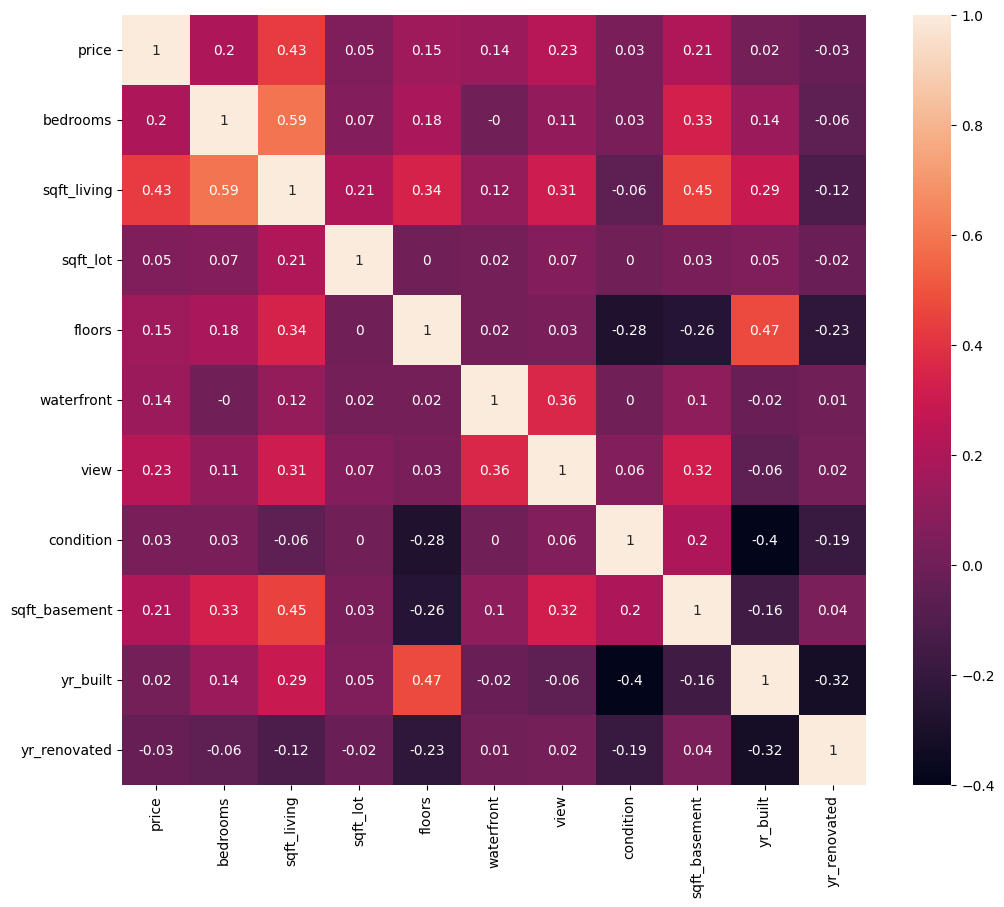

In [271]:
plt.figure(figsize=(12, 10))
sns.heatmap(np.round(df.select_dtypes(include='number').corr(), 2), annot=True, fmt='g')
plt.show()

In [272]:
df.drop(columns=['sqft_above', 'bathrooms'], inplace=True, errors='ignore')

In [278]:
df['date'] = pd.to_datetime(df['date'])

CURRENT_YEAR = df['date'].dt.year.max()

df['R_raw'] = np.where(
  df['yr_renovated'] > 0,
  CURRENT_YEAR - df['yr_renovated'],
  CURRENT_YEAR - df['yr_built']
)

df['R'] = 1 / (df['R_raw'] + 1)

zip_counts = df.groupby('statezip')['date'].transform('count')
df['F'] = zip_counts

df['M'] = np.log(df['price'])

df['R_q'] = df['R'].rank(method='max', pct=True)
df['F_q'] = df['F'].rank(method='max', pct=True)
df['M_q'] = df['M'].rank(method='max', pct=True)

df['RFM_score'] = 0.3*df['R_q'] + 0.3*df['F_q'] + 0.4*df['M_q']

df['RFM_segment'] = (
  df['R_q'].apply(lambda x: int(x*4)+1).astype(str) +
  df['F_q'].apply(lambda x: int(x*4)+1).astype(str) +
  df['M_q'].apply(lambda x: int(x*4)+1).astype(str)
)

df[['R_raw','R','F','M','RFM_score','RFM_segment']].head()

,R_raw,R,F,M,RFM_score,RFM_segment
0,9,0.100000,93,12.653958,0.530543,431
1,93,0.010638,49,14.684290,0.459587,114
2,48,0.020408,100,12.742566,0.423283,142
3,51,0.019231,50,12.948010,0.279261,112
4,22,0.043478,135,13.217674,0.683283,243


In [ ]:
X = df[['R_q','F_q','M_q','RFM_score']].values
y = df['price'].values

In [295]:
ss_y = StandardScaler()
y_scaled = ss_y.fit_transform(y.reshape(-1, 1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(
  X, y_scaled, test_size=0.2, random_state=42
)

In [357]:
from keras.layers import LeakyReLU

model = Sequential([
  Input(shape=(X_train.shape[1],)),
  Dense(64, activation=None, kernel_regularizer=L2(0.01)),
  LeakyReLU(0.01),
  Dropout(0.3),
  Dense(32, activation=None, kernel_regularizer=L2(0.01)),
  LeakyReLU(0.01),
  Dropout(0.3),
  Dense(1)
])

model.compile(
  optimizer=Adam(),
  loss='mean_squared_error',
  metrics=['mean_absolute_error']
)

In [358]:
early_stop = EarlyStopping('val_loss', patience=5)

history = model.fit(
  X_train, y_train,
  batch_size=32, epochs=10,
  validation_split=0.2,
  callbacks=[early_stop]
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7184 - mean_absolute_error: 0.3625 - val_loss: 0.3832 - val_mean_absolute_error: 0.1923
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4454 - mean_absolute_error: 0.2623 - val_loss: 0.2553 - val_mean_absolute_error: 0.1561
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3506 - mean_absolute_error: 0.2254 - val_loss: 0.2031 - val_mean_absolute_error: 0.1386
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2943 - mean_absolute_error: 0.2029 - val_loss: 0.1727 - val_mean_absolute_error: 0.1406
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2824 - mean_absolute_error: 0.2011 - val_loss: 0.1571 - val_mean_absolute_error: 0.1235
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2544 - mean_absolute_error: 0.1930 - val_loss: 0.1435 - val_mean_absolute_error: 0.1177
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2428 - mean_absolute_error: 0.1849 - val_loss: 0.132

In [359]:
y_pred = model.predict(X_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


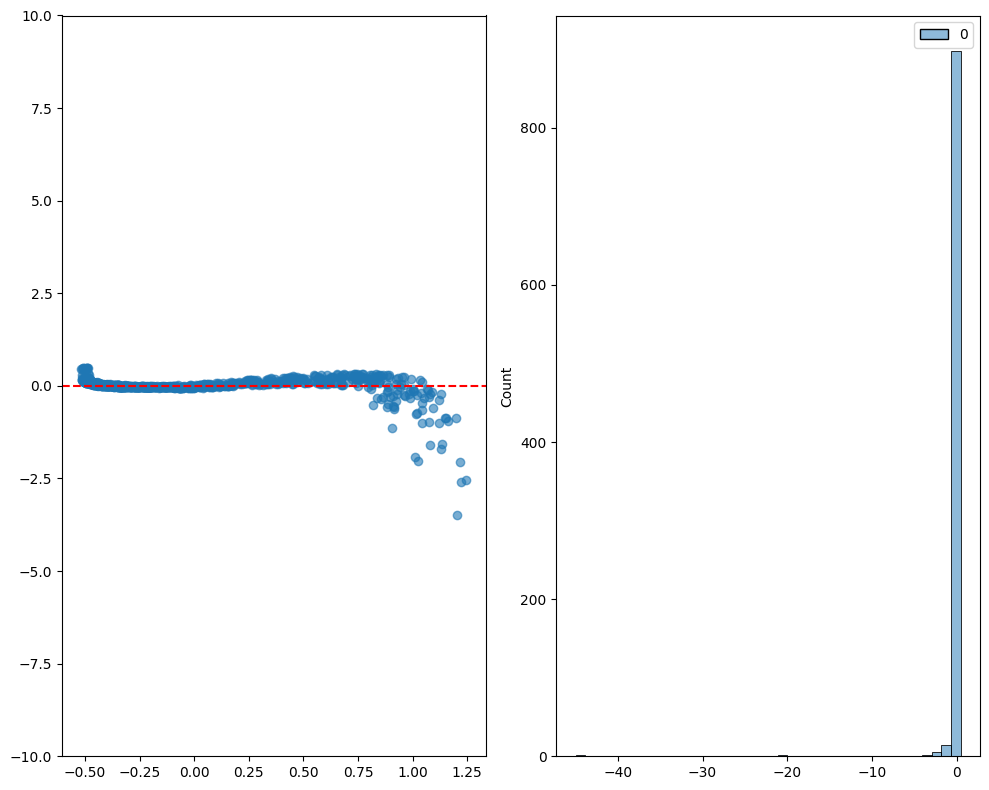

In [360]:
residuals = y_pred - np.array(y_test).reshape((920, 1))

plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--', color='red')
plt.ylim(-10, 10)

plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=40, ec='black')

plt.tight_layout()
plt.show()

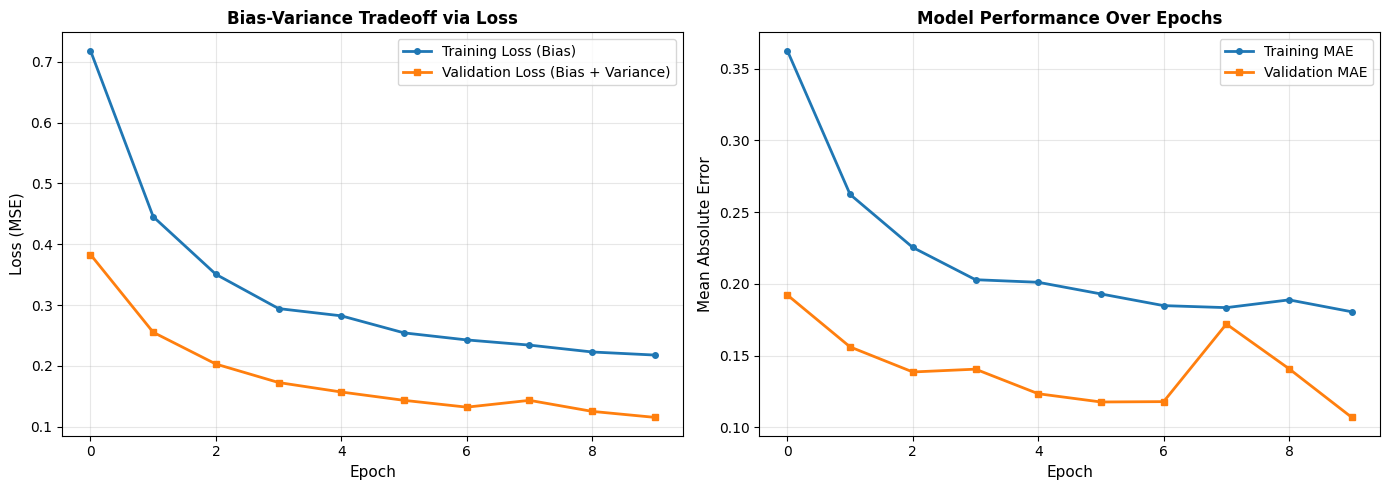


BIAS-VARIANCE ANALYSIS (Regression)

Final Training Loss (MSE): 0.2179 (Bias - underfitting)
Final Validation Loss (MSE): 0.1154 (Bias + Variance)
Gap (Variance component): -0.1025

Training MAE: $0.1806 (scaled)
Validation MAE: $0.1070 (scaled)

✓ Excellent fit: Low variance, good generalization


In [362]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss (Bias)', linewidth=2, marker='o', markersize=4)
plt.plot(history.history['val_loss'], label='Validation Loss (Bias + Variance)', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss (MSE)', fontsize=11)
plt.title('Bias-Variance Tradeoff via Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE', linewidth=2, marker='o', markersize=4)
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Mean Absolute Error', fontsize=11)
plt.title('Model Performance Over Epochs', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
gap = final_val_loss - final_train_loss

final_train_mae = history.history['mean_absolute_error'][-1]
final_val_mae = history.history['val_mean_absolute_error'][-1]

print(f"\nFinal Training Loss (MSE): {final_train_loss:.4f} (Bias - underfitting)")
print(f"Final Validation Loss (MSE): {final_val_loss:.4f} (Bias + Variance)")
print(f"Gap (Variance component): {gap:.4f}")

print(f"\nTraining MAE: ${final_train_mae:.4f} (scaled)")
print(f"Validation MAE: ${final_val_mae:.4f} (scaled)")

In [361]:
x_test = np.array([[
  0.82,   # R_q  (recently renovated or newer house)
  0.41,   # F_q  (mid-activity ZIP code)
  0.67,   # M_q  (upper-middle monetary tier)
  0.63   # RFM_score (solid overall segment)
]])

price = model.predict(x_test)

print(f"Price: ${ss_y.inverse_transform(price)[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Price: $579696.375
